# Prueba Microcredencial Gestión de Carteras con Python
26/03/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import missingno as mso
import cvxpy as cp
import statsmodels.api as sm
from pandas_datareader import data as pdr

## Ejercicio 1
Descarga de datos y análisis inicial.

In [2]:
tickers = [
    "VTI",  # Vanguard Total Stock Market (Mercado total EE.UU.)
    "QQQ",  # Invesco QQQ Trust (Tecnología Nasdaq 100)
    "BTC-USD",  # Bitcoin (Activo de riesgo/liquidez global)
    "ASML",  # ASML Holding (Semiconductores, ciclo de innovación)
    "XWD.TO",  # iShares MSCI World ETF (Renta variable global)
    "GLD",  # SPDR Gold Shares  (Oro, refugio de valor)
    "USO",  # United States Oil Fund, LP (Petróleo, energía)
    "AGZD",  # WisdomTree Interest Rate Hedged U.S. Aggregate Bond Fund (Cobertura de tipos)
    "DBA",  # Invesco DB Agriculture Fund (Materias primas agrícolas)
    "VNQ",  # Vanguard Real Estate Index Fund ETF Shares (Bienes raíces)
    "SH",  # ProShares Short S&P500 (Inverso del mercado)
    "VXX",  # iPath Series B S&P 500 VIX Short-Term Futures ETN (Volatilidad/Miedo)
    "TLT",  # iShares 20+ Year Treasury Bond ETF (Bonos largo plazo)
    "PSQ",  # ProShares Short QQQ (Inverso de tecnología)
]
data = yf.download(tickers, start="2016-01-01", end="2026-03-25", auto_adjust=True)["Close"]

[*********************100%***********************]  14 of 14 completed


In [3]:
data_idx = yf.download("SPY", start=data.index.min(), end=data.index.max(), auto_adjust=True)["Close"]


[*********************100%***********************]  1 of 1 completed


Visualización rápida de los precios.

<Axes: xlabel='Date'>

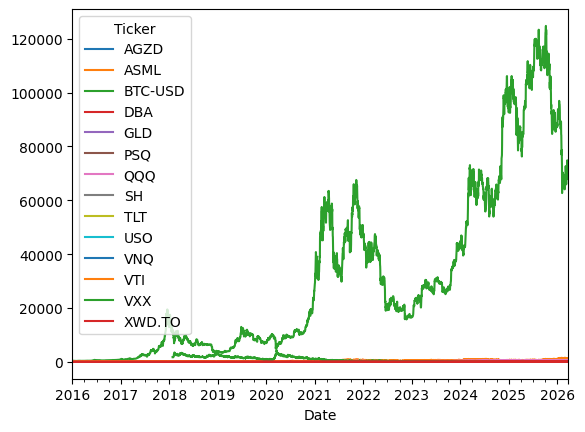

In [4]:
data.plot()

Visualización de datos faltantes

<Axes: >

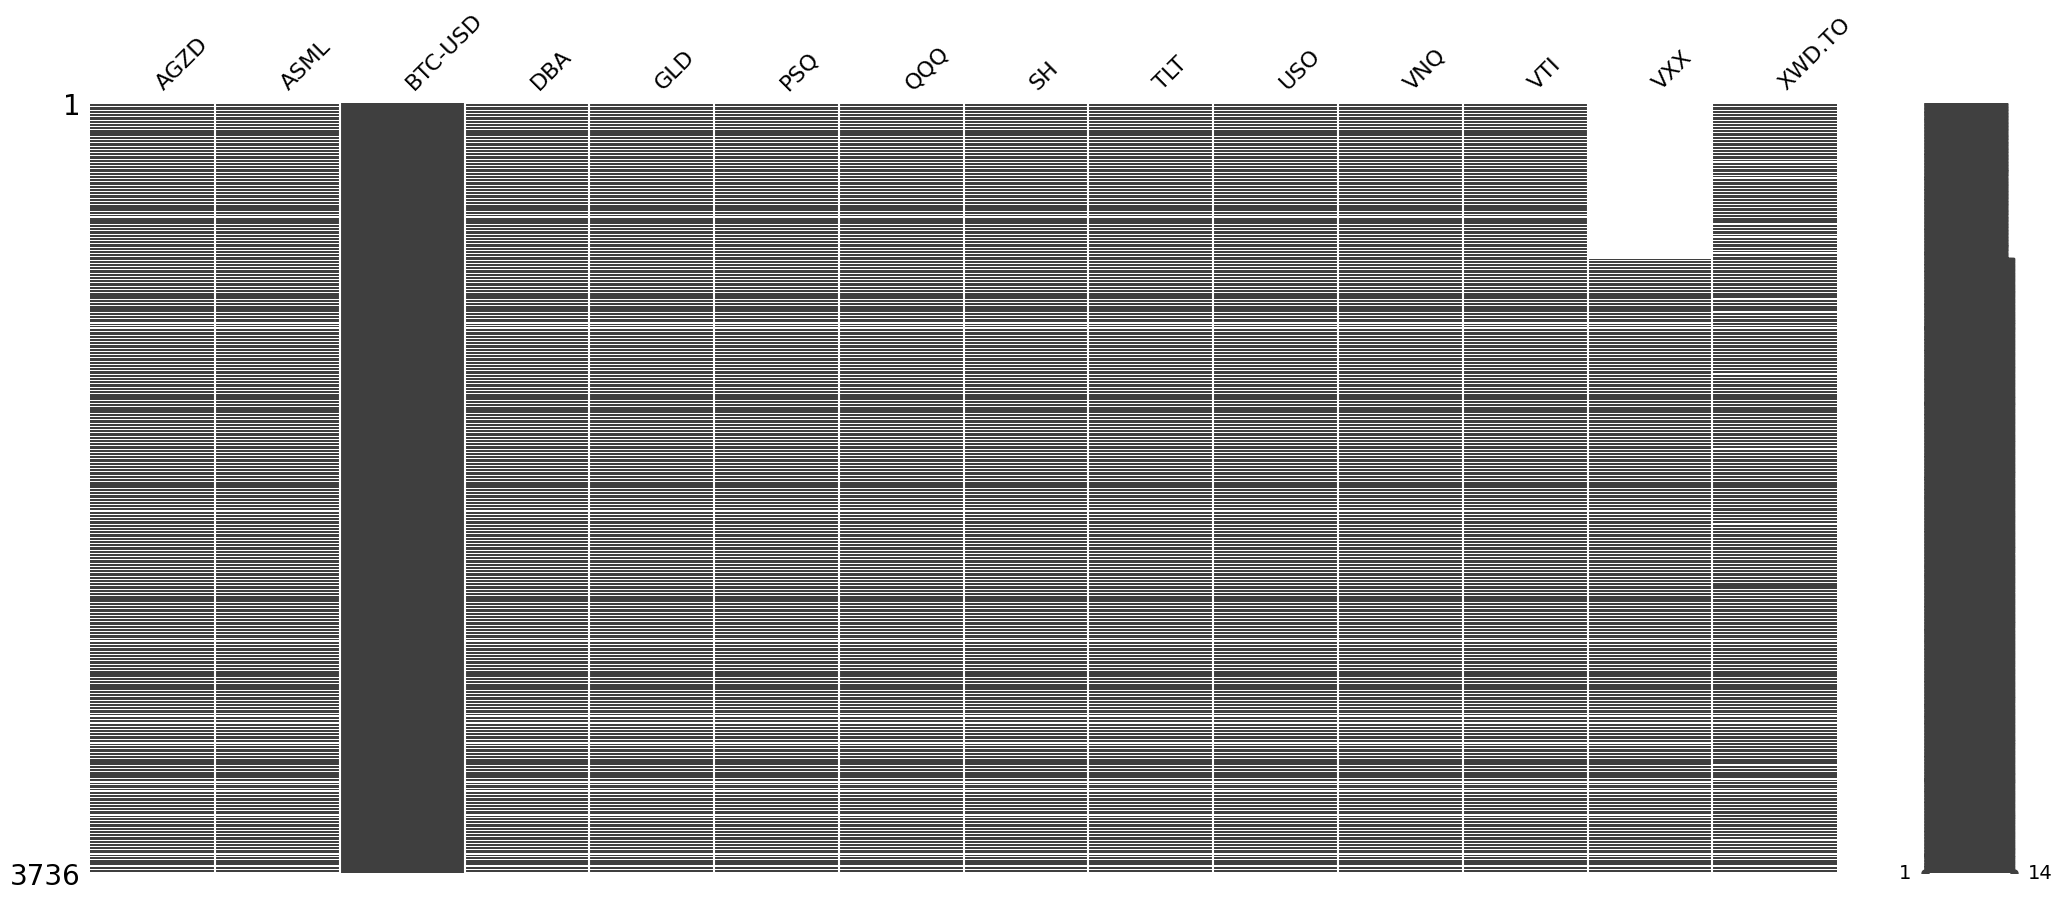

In [5]:
mso.matrix(data)

Limpieza de datos

In [6]:
data = data.dropna(axis=1, how="all")
data = data.dropna(axis=0, how="any")

<Axes: >

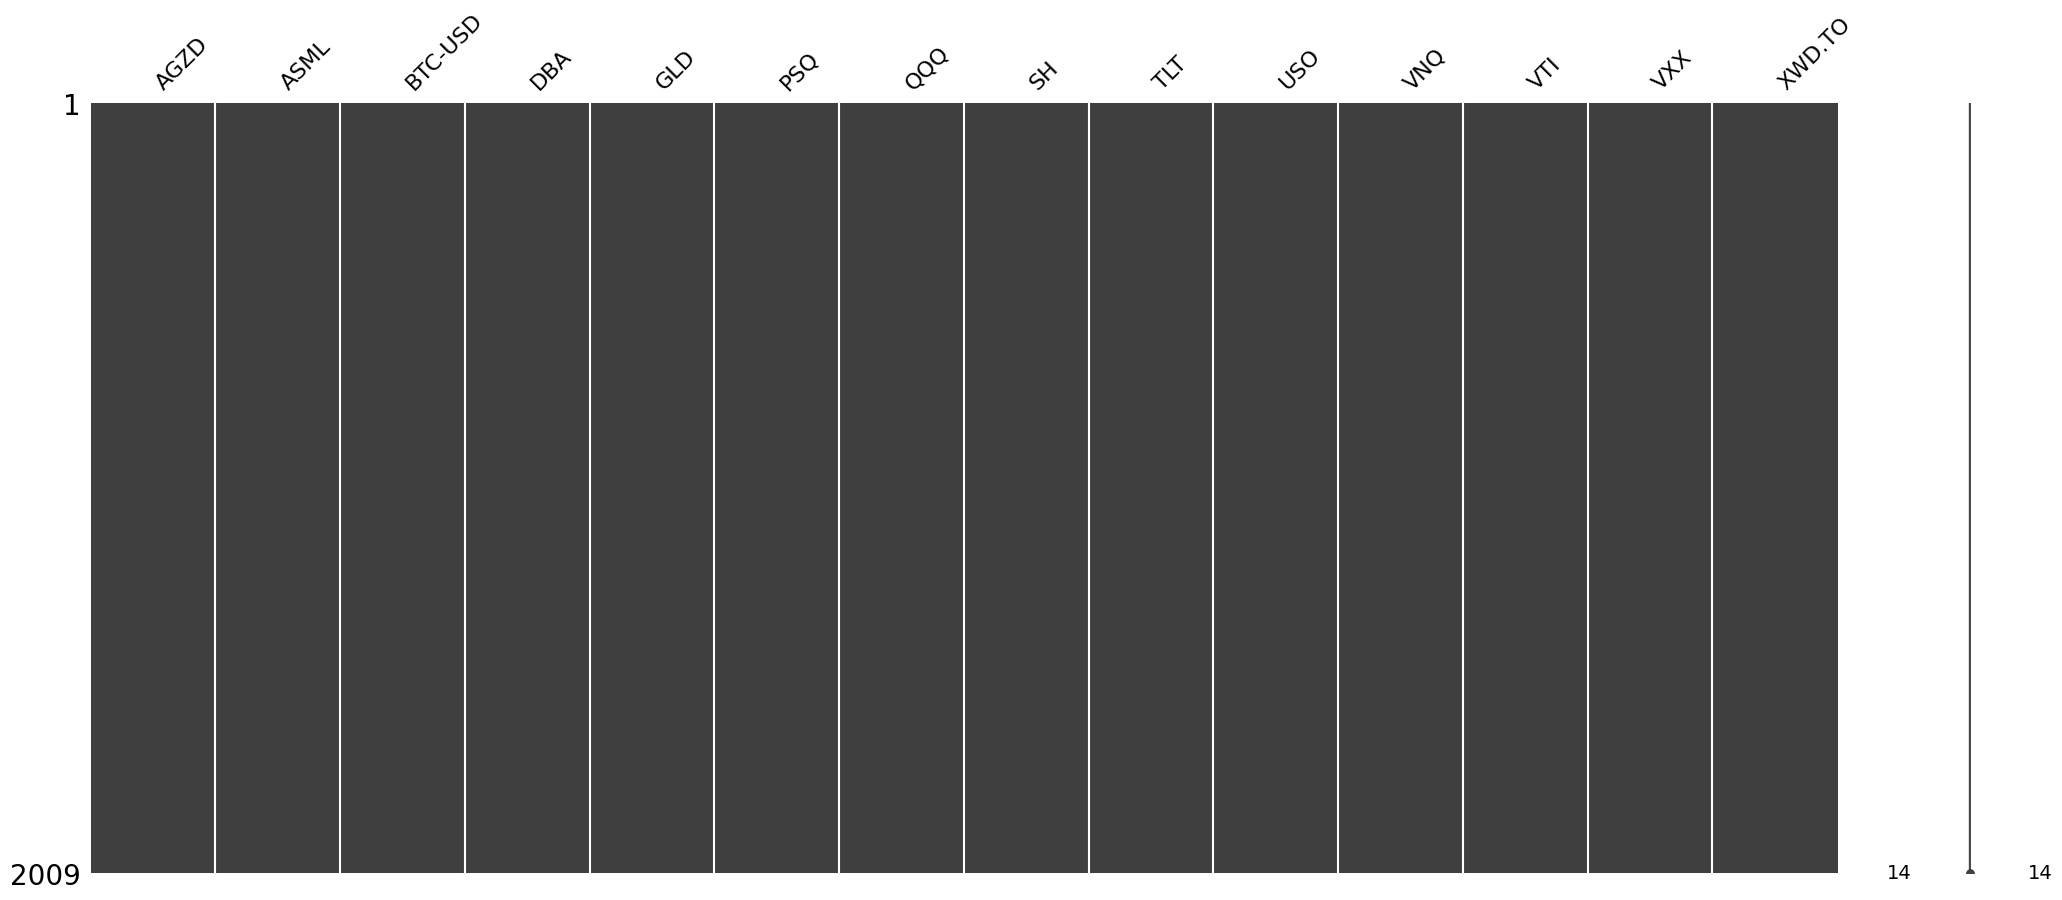

In [7]:
mso.matrix(data)


Alinea los dataframes de precios de los activos con el del índice.

In [8]:
data, data_idx = data.align(data_idx, join="inner", axis=0)

Descripción básica de la estructura del dataframe de precios

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2008 entries, 2018-01-25 to 2026-03-23
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AGZD     2008 non-null   float64
 1   ASML     2008 non-null   float64
 2   BTC-USD  2008 non-null   float64
 3   DBA      2008 non-null   float64
 4   GLD      2008 non-null   float64
 5   PSQ      2008 non-null   float64
 6   QQQ      2008 non-null   float64
 7   SH       2008 non-null   float64
 8   TLT      2008 non-null   float64
 9   USO      2008 non-null   float64
 10  VNQ      2008 non-null   float64
 11  VTI      2008 non-null   float64
 12  VXX      2008 non-null   float64
 13  XWD.TO   2008 non-null   float64
dtypes: float64(14)
memory usage: 235.3 KB


Desripción estadística básica de los precios

In [10]:
data.describe()

Ticker,AGZD,ASML,BTC-USD,DBA,GLD,PSQ,QQQ,SH,TLT,USO,VNQ,VTI,VXX,XWD.TO
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000
mean,19.160143,555.523250,38525.006211,18.266240,191.856041,68.695968,330.769024,61.461206,102.944261,72.524044,75.533362,202.281829,839.146961,66.676495
std,1.494198,291.646662,32535.792914,4.337717,74.218981,35.105740,134.628200,21.081722,18.122994,22.918245,11.131521,63.139949,914.401152,19.603676
min,16.863874,135.028641,3242.484863,11.612879,111.099998,28.860777,137.163345,35.232899,74.837929,17.040001,45.223991,102.467766,25.750000,39.245560
25%,18.145013,271.952003,9524.767822,14.656065,147.630001,40.574757,203.178440,44.974602,87.664112,63.162500,67.054314,141.854271,59.957500,49.644981
50%,18.489419,590.971161,28654.055664,17.479423,171.970001,54.955559,313.558121,52.594564,96.146969,73.199997,74.983170,197.187813,372.000000,62.866352
75%,20.316481,730.817322,60285.195312,20.810542,199.035000,102.518396,426.495941,83.671886,118.217682,86.980000,86.411890,244.575562,1629.120026,80.002995
max,22.559999,1526.510010,124752.531250,27.392115,495.899994,153.146225,634.152344,111.567291,144.897537,128.639999,98.083687,343.269989,4416.000000,113.089996


Cálculo de los retornos logarítmicos

In [11]:
ret = np.log(data).diff().dropna()

Descripción estadística básica de los retornos

In [12]:
ret.describe()

Ticker,AGZD,ASML,BTC-USD,DBA,GLD,PSQ,QQQ,SH,TLT,USO,VNQ,VTI,VXX,XWD.TO
count,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,0.000127,0.000996,0.000917,0.000254,0.000573,-0.000722,0.000650,-0.000455,-0.000066,0.000028,0.000209,0.000463,-0.001965,0.000431
std,0.002398,0.025843,0.041077,0.008663,0.010461,0.015198,0.015234,0.012351,0.009918,0.025865,0.014145,0.012569,0.044793,0.010409
min,-0.022260,-0.190545,-0.464730,-0.049865,-0.108412,-0.125441,-0.127592,-0.098178,-0.069010,-0.291891,-0.195136,-0.120822,-0.231166,-0.102733
25%,-0.000912,-0.012284,-0.016399,-0.004883,-0.004463,-0.008719,-0.006109,-0.006406,-0.005988,-0.011830,-0.006128,-0.004647,-0.026429,-0.003797
50%,0.000000,0.001088,0.000970,0.000000,0.000646,-0.001161,0.001286,-0.000768,0.000138,0.001311,0.000743,0.000897,-0.006328,0.000710
75%,0.001331,0.016048,0.019677,0.005444,0.005865,0.006204,0.008645,0.004604,0.005747,0.013471,0.007271,0.006824,0.015849,0.005480
max,0.021936,0.143530,0.203046,0.029828,0.061647,0.108016,0.113356,0.108949,0.072503,0.154151,0.086147,0.096633,0.315250,0.085220


Visualización de los retornos

<Axes: xlabel='Date'>

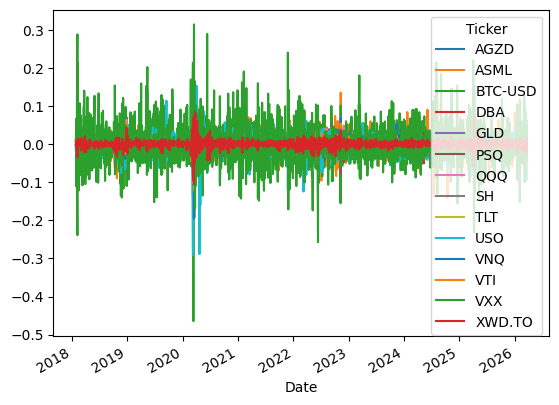

In [13]:
ret.plot()

Visualización de las distribuciones de los retornos

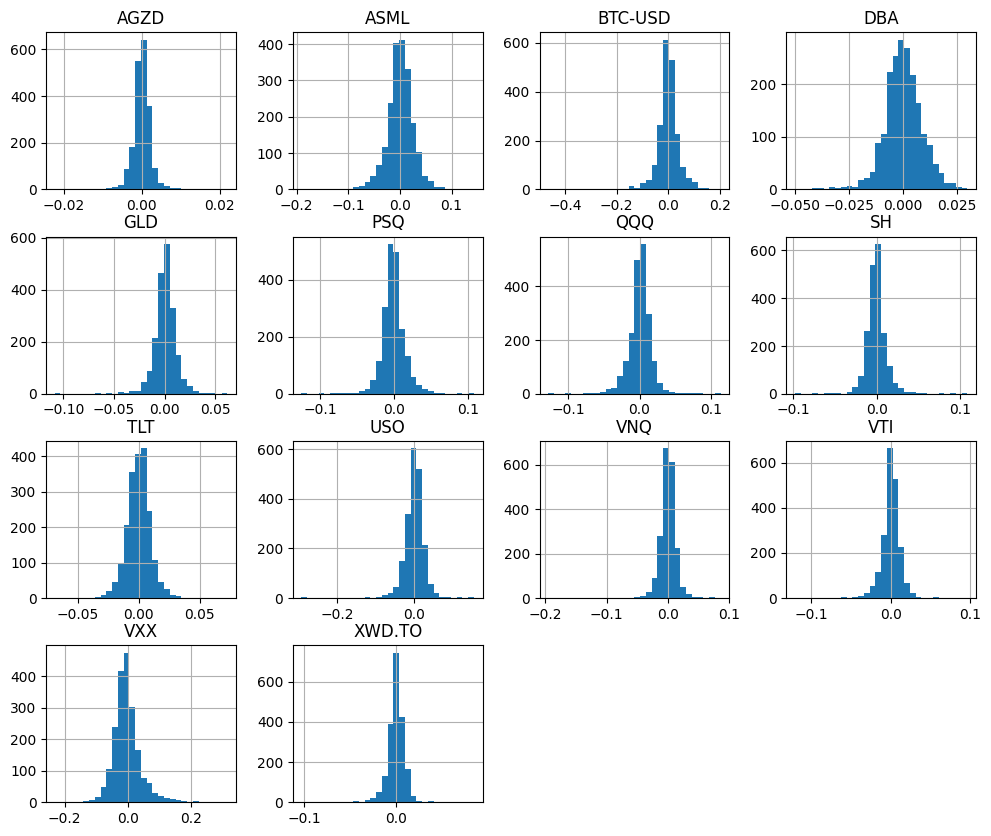

In [14]:
ret.hist(figsize=(12, 10), bins=30)
plt.show()

Cálculo de skewness y kurtosis de los retornos

In [15]:
ret.skew().sort_values()

Ticker
USO       -1.793127
VNQ       -1.580816
BTC-USD   -0.884970
GLD       -0.801354
VTI       -0.588475
XWD.TO    -0.548448
AGZD      -0.392078
DBA       -0.370304
QQQ       -0.351128
ASML      -0.337915
PSQ       -0.074353
SH         0.022642
TLT        0.062381
VXX        1.252203
dtype: float64

In [16]:
ret.kurt().sort_values()


Ticker
DBA         2.179590
ASML        4.000934
TLT         4.799619
VXX         5.989432
PSQ         6.621217
QQQ         6.876813
GLD         8.970708
BTC-USD    11.502459
SH         13.372630
VTI        13.528515
AGZD       14.728258
XWD.TO     17.115117
USO        20.710187
VNQ        24.563270
dtype: float64

Grafica los retornos de "USO" (United States Oil Fund (Petróleo, energía)) y "BIL" (SPDR Bloomberg 1-3 Month T-Bill)

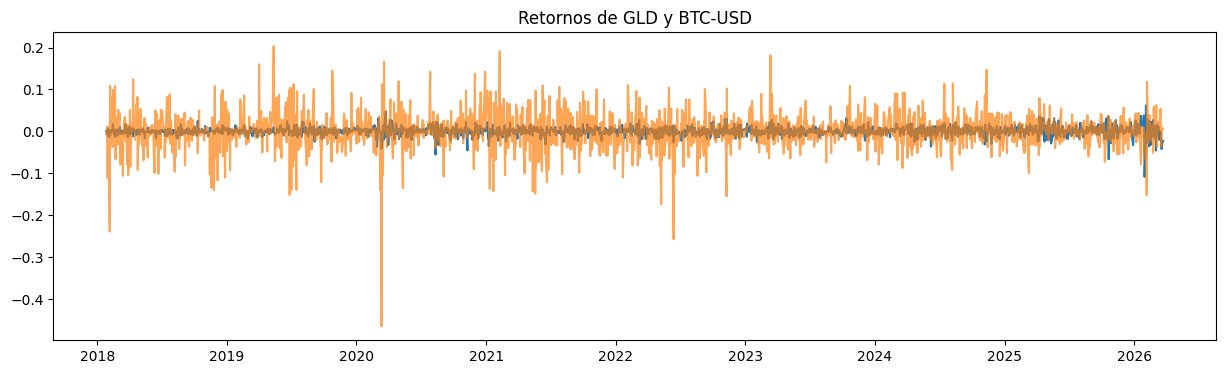

In [17]:
plt.figure(figsize=(15, 4))
plt.plot(ret.loc[:, ["GLD"]])
plt.plot(ret.loc[:, ["BTC-USD"]], alpha=0.7)
plt.title("Retornos de GLD y BTC-USD")
plt.show()

Visualización de la relación por pares entre los retornos

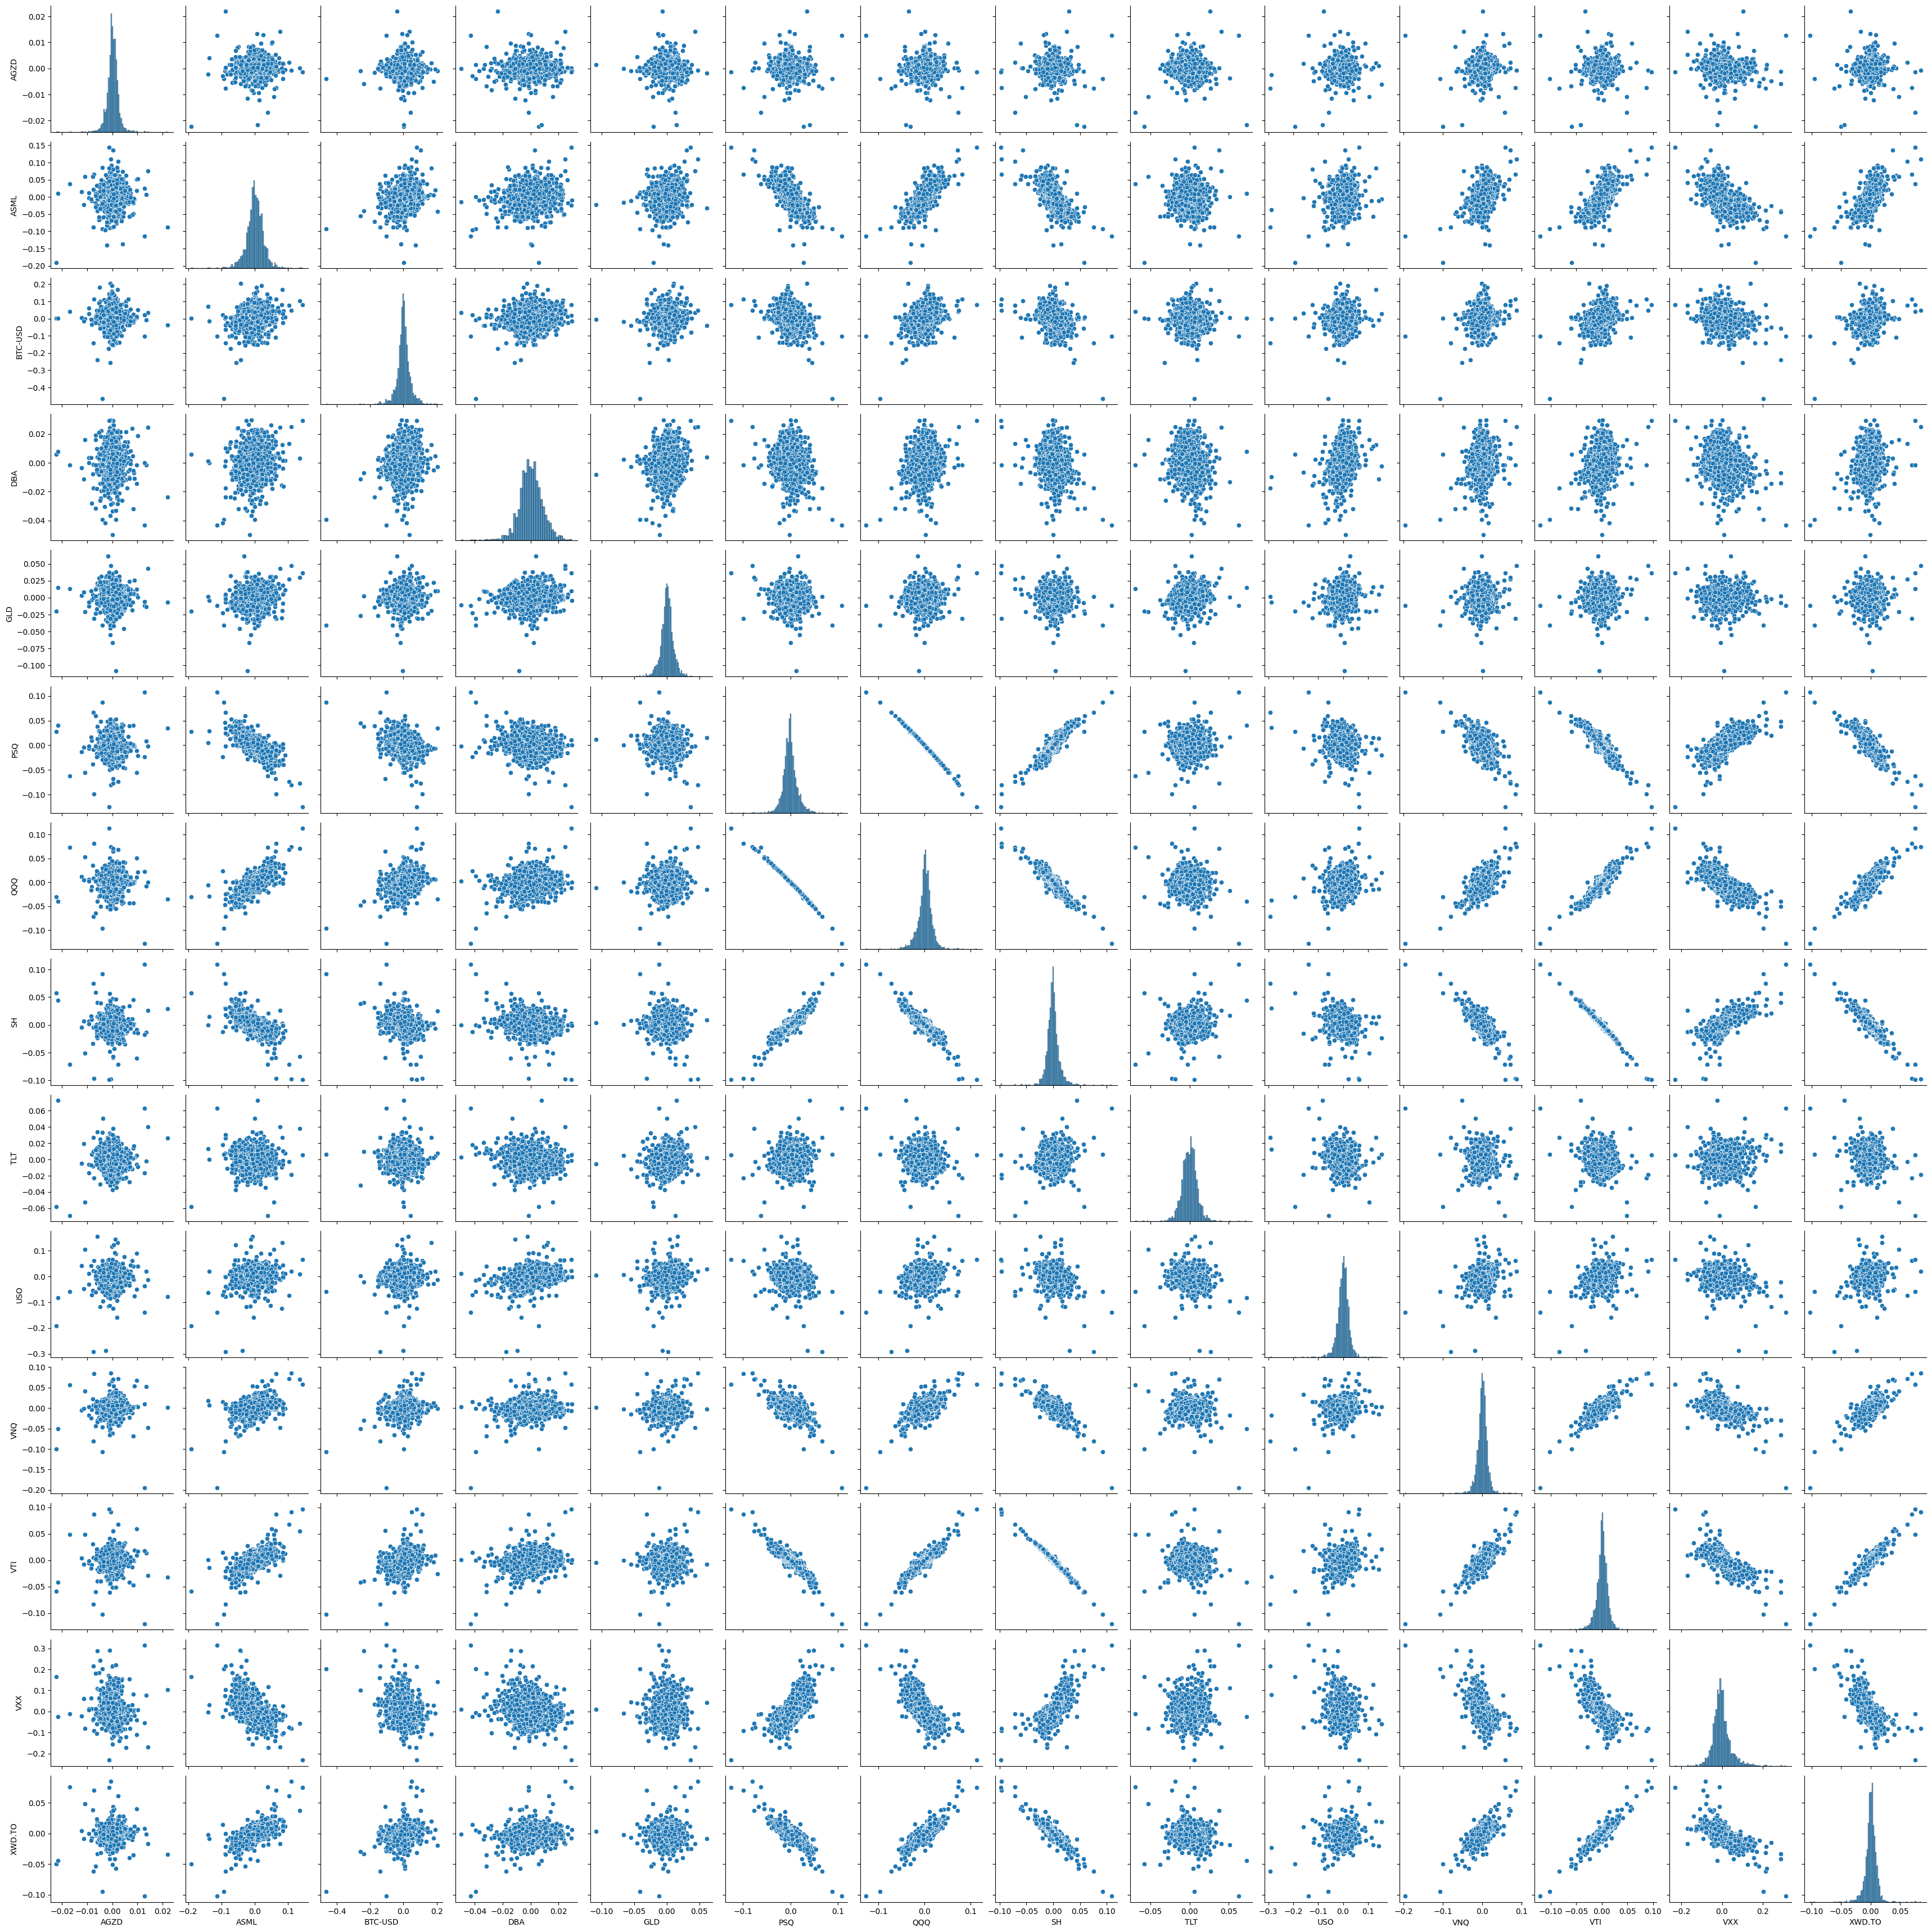

In [18]:
sns.pairplot(ret)
plt.show()

Visualización de la matriz de correlación de los retornos

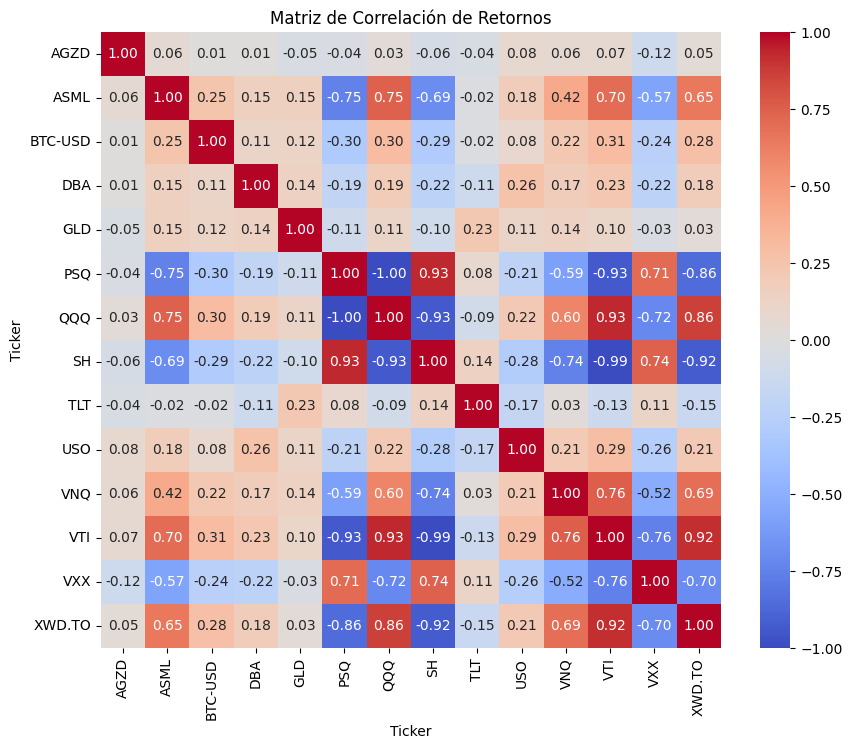

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(ret.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmax=1, vmin=-1)
plt.title("Matriz de Correlación de Retornos")
plt.show()

## Ejercicio 2

Calcula los retornos del SPY

In [20]:
ret_idx = np.log(data_idx).diff().dropna()
ret_idx

Ticker,SPY
Date,
2018-01-26,0.011511
2018-01-29,-0.006652
2018-01-30,-0.010310
2018-01-31,0.000497
2018-02-01,-0.001136
...,...
2026-03-17,0.002627
2026-03-18,-0.014052
2026-03-19,-0.002467


Crea una cartera equi-ponderada con todos los activos y calcula la serie de retornos.

In [21]:
pesos_eq = np.ones(len(data.columns)) / len(data.columns)
ret_cartera = ret @ pesos_eq
ret_cartera.shape

(2007,)

Grafica los retornos acumulados de la cartera y del índice SPY.

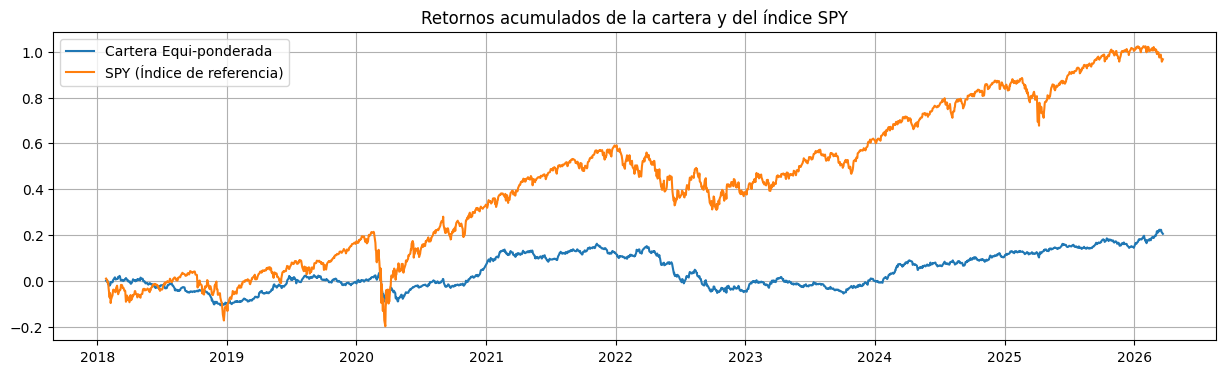

In [22]:
plt.figure(figsize=(15, 4))
plt.plot(ret_cartera.cumsum(), label="Cartera Equi-ponderada")
plt.plot(ret_idx.cumsum(), label="SPY (Índice de referencia)")
plt.title("Retornos acumulados de la cartera y del índice SPY")
plt.grid(True)
plt.legend()
plt.show()


Calcula el retorno medio anualizado de la cartera y del índice SPY.

In [23]:
mu_idx = np.mean(ret_idx) * 252
mu_p = np.mean(ret_cartera) * 252
print(f"Retorno medio anualizado del índice SPY: {mu_idx:.2%}")
print(f"Retorno medio anualizado de la cartera: {mu_p:.2%}")

Retorno medio anualizado del índice SPY: 12.13%
Retorno medio anualizado de la cartera: 2.59%


Calcula la volatilidad anualizada de la cartera y del índice SPY.

In [24]:
sigma_idx = np.std(ret_idx.values) * np.sqrt(252)
sigma_p = np.std(ret_cartera.values) * np.sqrt(252)
print(f"Volatilidad anualizada del índice SPY: {sigma_idx:.2%}")
print(f"Volatilidad anualizada de la cartera: {sigma_p:.2%}")

Volatilidad anualizada del índice SPY: 19.56%
Volatilidad anualizada de la cartera: 7.65%


Calcula el Ratio de Sharpe de la cartera y del índice SPY, asumiendo una tasa libre de riesgo del 0.0% anual.

In [25]:
rf = 0.0
sharpe_idx = (mu_idx - rf) / sigma_idx
sharpe_p = (mu_p - rf) / sigma_p
print(f"Ratio de Sharpe del índice SPY: {sharpe_idx:.2f}")
print(f"Ratio de Sharpe de la cartera: {sharpe_p:.2f}")

Ratio de Sharpe del índice SPY: 0.62
Ratio de Sharpe de la cartera: 0.34


## Ejercicio 3

Calcula la cartera de máximo Ratio de Sharpe sin posiciones cortas, asumiendo una tasa libre de riesgo del 0.0% anual.

In [26]:
pseudo_pesos_max_sharpe = cp.Variable(len(ret.columns))
Sigma = ret.cov().values
rf = 0.0
ret_max_sharpe = ret.values @ pseudo_pesos_max_sharpe
mu_max_sharpe = cp.mean(ret_max_sharpe)
pi_max_sharpe = mu_max_sharpe - rf
var_max_sharpe = cp.quad_form(pseudo_pesos_max_sharpe, Sigma)

objetivo = cp.Minimize(var_max_sharpe)

restricciones = [
    pi_max_sharpe == 1,  # Cambio de variable numerador Ratio Sharpe
    pseudo_pesos_max_sharpe >= 0,  # No se permiten posiciones cortas
]

problema = cp.Problem(objetivo, restricciones)
problema.solve()

pesos_max_sharpe = pseudo_pesos_max_sharpe.value / np.sum(pseudo_pesos_max_sharpe.value)  # Normalizar para que sumen 1


In [27]:
# Verificar si se encontró una solución óptima
if problema.status == cp.OPTIMAL:
    # Resultados
    print(f"Optimización exitosa. Valor óptimo: {problema.value}")
else:
    print(f"No se pudo encontrar una solución óptima. Estado: {problema.status}")
    if problema.status == cp.INFEASIBLE:
        print("El problema es infactible. Las restricciones no pueden satisfacerse simultáneamente.")
    elif problema.status == cp.UNBOUNDED:
        print("El problema es no acotado. La función objetivo puede mejorarse indefinidamente.")
    elif problema.status == cp.OPTIMAL_INACCURATE:
        print("Se encontró una solución óptima pero con precisión reducida.")


Optimización exitosa. Valor óptimo: 115.53121077010772


Grafica los pesos de la cartera de máxima Ratio de Sharpe en un gráfico de barras.

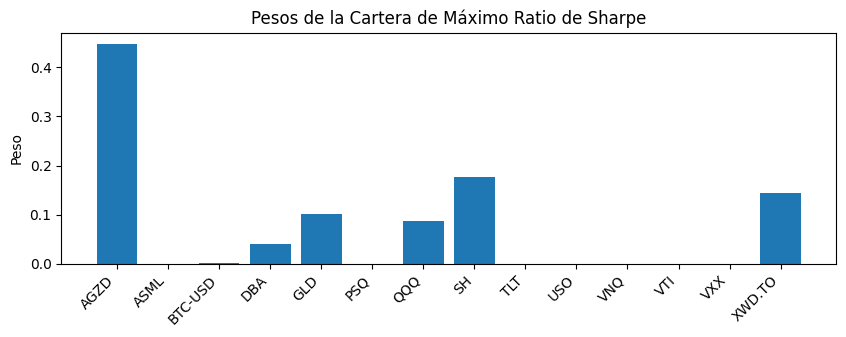

In [28]:
plt.figure(figsize=(10, 3))
plt.bar(data.columns, pesos_max_sharpe)
plt.xticks(rotation=45, ha="right")
plt.title("Pesos de la Cartera de Máximo Ratio de Sharpe")
plt.ylabel("Peso")
plt.show()

Calcula la cartera de máxima rentabilidad sin posiciones cortas.

In [29]:
pesos_max_rent = cp.Variable(len(ret.columns))
ret_max_rent = ret.values @ pesos_max_rent

objetivo = cp.Maximize(cp.mean(ret_max_rent))

restricciones = [
    cp.sum(pesos_max_rent) == 1,  # La suma de los pesos debe ser 1
    pesos_max_rent >= 0,  # No se permiten posiciones cortas
]

problema = cp.Problem(objetivo, restricciones)
problema.solve()

pesos_max_rent = pesos_max_rent.value

In [30]:
# Verificar si se encontró una solución óptima
if problema.status == cp.OPTIMAL:
    # Resultados
    print(f"Optimización exitosa. Valor óptimo: {problema.value}")
else:
    print(f"No se pudo encontrar una solución óptima. Estado: {problema.status}")
    if problema.status == cp.INFEASIBLE:
        print("El problema es infactible. Las restricciones no pueden satisfacerse simultáneamente.")
    elif problema.status == cp.UNBOUNDED:
        print("El problema es no acotado. La función objetivo puede mejorarse indefinidamente.")
    elif problema.status == cp.OPTIMAL_INACCURATE:
        print("Se encontró una solución óptima pero con precisión reducida.")


Optimización exitosa. Valor óptimo: 0.00099649419310934


Grafica los pesos de la cartera de máxima rentabilidad en un gráfico de barras.

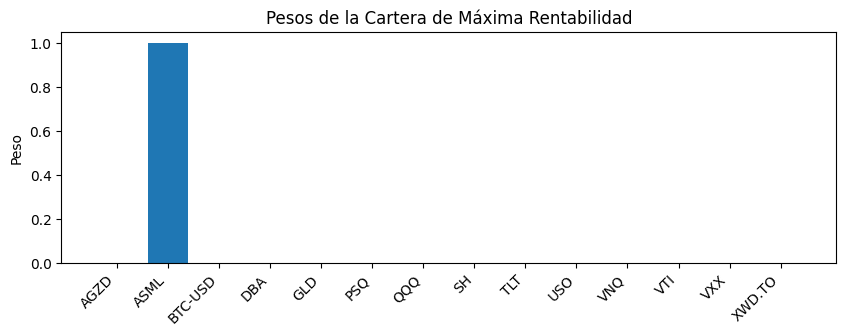

In [31]:
plt.figure(figsize=(10, 3))
plt.bar(data.columns, pesos_max_rent)
plt.xticks(rotation=45, ha="right")
plt.title("Pesos de la Cartera de Máxima Rentabilidad")
plt.ylabel("Peso")
plt.show()

Calcula la cartera de mínima volatilidad sin posiciones cortas.

In [32]:
pesos_min_vol = cp.Variable(len(ret.columns))
Sigma = ret.cov().values
var_min_vol = cp.quad_form(pesos_min_vol, Sigma)

objetivo = cp.Minimize(var_min_vol)

restricciones = [
    cp.sum(pesos_min_vol) == 1,  # La suma de los pesos debe ser 1
    pesos_min_vol >= 0,  # No se permiten posiciones cortas
]

problema = cp.Problem(objetivo, restricciones)
problema.solve()

pesos_min_vol = pesos_min_vol.value


In [33]:
# Verificar si se encontró una solución óptima
if problema.status == cp.OPTIMAL:
    # Resultados
    print(f"Optimización exitosa. Valor óptimo: {problema.value}")
else:
    print(f"No se pudo encontrar una solución óptima. Estado: {problema.status}")
    if problema.status == cp.INFEASIBLE:
        print("El problema es infactible. Las restricciones no pueden satisfacerse simultáneamente.")
    elif problema.status == cp.UNBOUNDED:
        print("El problema es no acotado. La función objetivo puede mejorarse indefinidamente.")
    elif problema.status == cp.OPTIMAL_INACCURATE:
        print("Se encontró una solución óptima pero con precisión reducida.")


Optimización exitosa. Valor óptimo: 2.1294878353469091e-07


Grafica los pesos de la cartera de mínima volatilidad en un gráfico de barras.

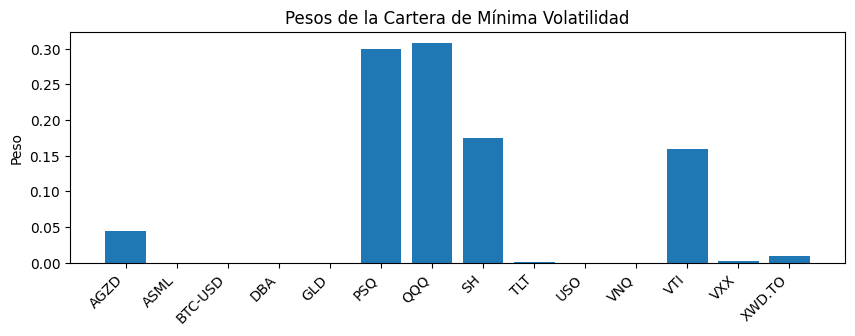

In [34]:
plt.figure(figsize=(10, 3))
plt.bar(data.columns, pesos_min_vol)
plt.xticks(rotation=45, ha="right")
plt.title("Pesos de la Cartera de Mínima Volatilidad")
plt.ylabel("Peso")
plt.show()

Toma la cartera de máximo Ratio de Sharpe y la cartera de mínima volatilidad, y calcula 100 carteras como combinaciones lineales de estas dos. Calcula el retorno esperado anualizado y la volatilidad anualizada de cada una de estas carteras y grafícalas en el espacio rentabilidad-riesgo. Marca la posición de la cartera de máxima rentabilidad, la cartera de mínima volatilidad y la cartera de máximo Ratio de Sharpe en el mismo gráfico.

In [35]:
# Alternativa 1.
pesos = np.linspace(-5, 15, 100)

ret_max_sharpe = ret.values @ pesos_max_sharpe
ret_min_vol = ret.values @ pesos_min_vol
ret_max_rent = ret.values @ pesos_max_rent

mu_max_sharpe = np.mean(ret_max_sharpe)
mu_min_vol = np.mean(ret_min_vol)

Sigma = np.cov([ret_max_sharpe, ret_min_vol])

rentabilidades = []
volatilidades = []
for w1 in pesos:
    w2 = 1 - w1
    pesos_cartera_comb = np.array([w1, w2])
    mu_cartera_comb = pesos_cartera_comb @ np.array([mu_max_sharpe, mu_min_vol])
    sigma_cartera_comb = np.sqrt(pesos_cartera_comb @ Sigma @ pesos_cartera_comb)

    rentabilidades.append(mu_cartera_comb)
    volatilidades.append(sigma_cartera_comb)


In [36]:
# Alternativa 2.
pesos = np.linspace(-5, 15, 100)

ret_max_rent = ret.values @ pesos_max_rent

rentabilidades = []
volatilidades = []
for w1 in pesos:
    w2 = 1 - w1
    cartera_comb = w1 * pesos_max_sharpe + w2 * pesos_min_vol
    ret_cartera_comb = ret.values @ cartera_comb
    mu_cartera_comb = np.mean(ret_cartera_comb)
    sigma_cartera_comb = np.std(ret_cartera_comb)

    rentabilidades.append(mu_cartera_comb)
    volatilidades.append(sigma_cartera_comb)

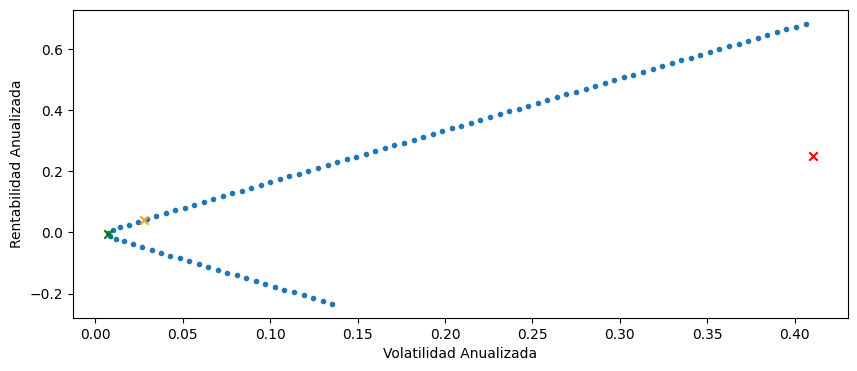

In [37]:
plt.figure(figsize=(10, 4))
plt.scatter(np.multiply(volatilidades, np.sqrt(252)), np.multiply(rentabilidades, 252), marker=".")
plt.scatter(
    np.std(ret_max_rent) * np.sqrt(252),
    np.mean(ret_max_rent) * 252,
    color="red",
    marker="x",
    label="Cartera de Máxima Rentabilidad",
)
plt.scatter(
    np.std(ret_min_vol) * np.sqrt(252),
    np.mean(ret_min_vol) * 252,
    color="green",
    marker="x",
    label="Cartera de Mínima Volatilidad",
)
plt.scatter(
    np.std(ret.values @ pesos_max_sharpe) * np.sqrt(252),
    np.mean(ret.values @ pesos_max_sharpe) * 252,
    color="orange",
    marker="x",
    label="Cartera de Máximo Ratio de Sharpe",
)
plt.xlabel("Volatilidad Anualizada")
plt.ylabel("Rentabilidad Anualizada")
plt.show()

Grafica los retornos acumulados de la cartera equi-ponderada, la cartera de máximo Ratio de Sharpe y del índice SPY.

In [38]:
ret_max_sharpe = pd.DataFrame(ret_max_sharpe, index=ret.index)


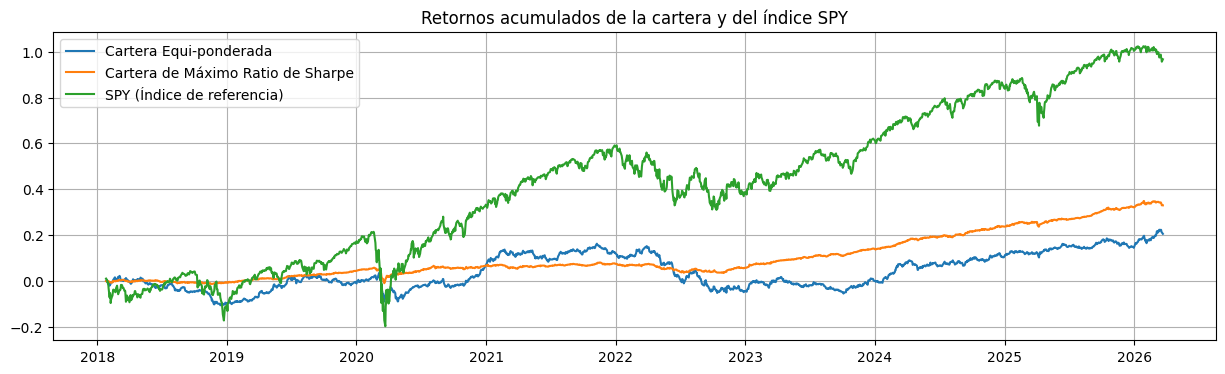

In [39]:
plt.figure(figsize=(15, 4))
plt.plot(ret_cartera.cumsum(), label="Cartera Equi-ponderada")
plt.plot(ret_max_sharpe.cumsum(), label="Cartera de Máximo Ratio de Sharpe")
plt.plot(ret_idx.cumsum(), label="SPY (Índice de referencia)")
plt.title("Retornos acumulados de la cartera y del índice SPY")
plt.grid(True)
plt.legend()
plt.show()


## Ejercicio 4


Filtra los retornos del índice entre las fechas del 1 de enero de 2021 y el 31 de diciembre de 2022.

In [40]:
ret_idx_filtrado = ret_idx.loc["2021-01-01":"2022-12-31", :]


Grafica los retornos acumulados en el período.

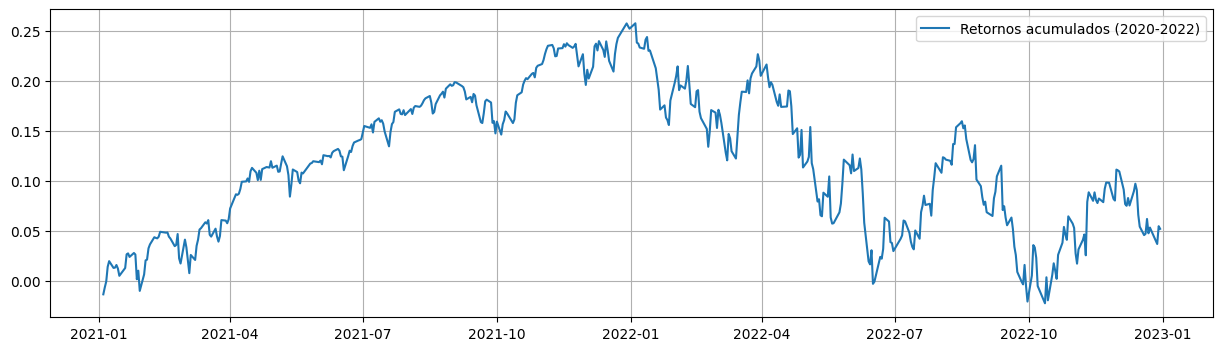

In [41]:
plt.figure(figsize=(15, 4))
plt.plot(ret_idx_filtrado.cumsum(), label="Retornos acumulados (2020-2022)")
plt.grid(True)
plt.legend()
plt.show()


Calcula la Beta del CAPM de Apple (APPL) con respecto al índice SPY en el período filtrado.

In [42]:
data_apple = yf.download("AAPL", start="2020-12-01", end=ret_idx_filtrado.index.max(), auto_adjust=True)["Close"]
ret_apple = np.log(data_apple).diff().dropna()
ret_idx_filtrado, ret_apple = ret_idx_filtrado.align(ret_apple, join="inner", axis=0)

[*********************100%***********************]  1 of 1 completed


In [43]:
y = ret_apple.values
X = sm.add_constant(ret_idx_filtrado.values)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     1003.
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.81e-120
Time:                        11:58:08   Log-Likelihood:                 1508.2
No. Observations:                 490   AIC:                            -3012.
Df Residuals:                     488   BIC:                            -3004.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.001     -0.702      0.4

Divide los retornos del índice en dos tramos:
1. Desde el 1 de enero de 2021 hasta el 31 de diciembre de 2021.
2. Desde el 1 de enero de 2022 hasta el 31 de diciembre de 2022.

In [44]:
ret_idx_tramo_alcista = ret_idx.loc["2021-01-01":"2021-12-31", :]
ret_idx_tramo_bajista = ret_idx.loc["2022-01-01":"2022-12-31", :]


Grafica los retornos acumulados de cada tramo.

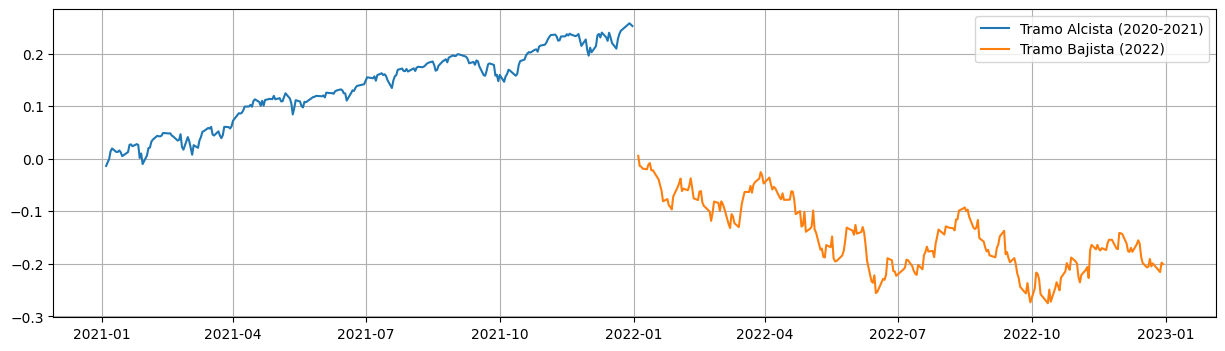

In [45]:
plt.figure(figsize=(15, 4))
plt.plot(ret_idx_tramo_alcista.cumsum(), label="Tramo Alcista (2020-2021)")
plt.plot(ret_idx_tramo_bajista.cumsum(), label="Tramo Bajista (2022)")
plt.grid(True)
plt.legend()
plt.show()


Calcula la Beta del CAPM de Apple (APPL) con respecto al índice SPY en cada tramo.

In [46]:
ret_idx_tramo_alcista, ret_apple_tramo_alcista = ret_idx_tramo_alcista.align(ret_apple, join="inner", axis=0)
ret_idx_tramo_bajista, ret_apple_tramo_bajista = ret_idx_tramo_bajista.align(ret_apple, join="inner", axis=0)

In [47]:
y = ret_apple_tramo_alcista.values
X = sm.add_constant(ret_idx_tramo_alcista.values)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     208.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.48e-34
Time:                        11:58:08   Log-Likelihood:                 745.97
No. Observations:                 246   AIC:                            -1488.
Df Residuals:                     244   BIC:                            -1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.001     -0.328      0.7

In [48]:
y = ret_apple_tramo_bajista.values
X = sm.add_constant(ret_idx_tramo_bajista.values)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     846.2
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           5.80e-81
Time:                        11:58:08   Log-Likelihood:                 763.38
No. Observations:                 244   AIC:                            -1523.
Df Residuals:                     242   BIC:                            -1516.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0005      0.001     -0.708      0.4

## Ejercicio 5


Descarga los datos de Fama & French correspondientes al año 2025.

In [49]:
start = "2025-01-01"
end = "2025-12-31"

ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start=start, end=end)

factors = ff[0].copy()
factors.index = factors.index.to_timestamp()
factors = factors / 100.0

C:\Users\pventura\AppData\Local\Temp\ipykernel_76988\3807053612.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start=start, end=end)
C:\Users\pventura\AppData\Local\Temp\ipykernel_76988\3807053612.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = pdr.DataReader("F-F_Research_Data_Factors", "famafrench", start=start, end=end)


Descarga los datos del fondo con ticker "BLCR"

In [54]:
data_fondo = yf.download("BLCR", start="2024-12-01", end="2025-12-31", auto_adjust=True)["Close"]

[*********************100%***********************]  1 of 1 completed


¿Qué tipo de fondo es "BLCR"? ¿Grandes o pequeñas empresas?

In [55]:
data_fondo = data_fondo.resample("BME").last().dropna()
ret_fondo = data_fondo.pct_change().dropna()

In [56]:
factors.shape, ret_fondo.shape

((12, 4), (12, 1))

In [57]:
y = ret_fondo.values
X = sm.add_constant(factors.loc[:, "SMB"].values)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     2.683
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.132
Time:                        11:58:28   Log-Likelihood:                 20.975
No. Observations:                  12   AIC:                            -37.95
Df Residuals:                      10   BIC:                            -36.98
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0316      0.014      2.262      0.0

¿Y el fondo "IJR"? ¿Grandes o pequeñas empresas?

In [58]:
data_fondo = yf.download("IJR", start="2024-12-01", end="2025-12-31", auto_adjust=True)["Close"]

[*********************100%***********************]  1 of 1 completed


In [59]:
data_fondo = data_fondo.resample("BME").last().dropna()
ret_fondo = data_fondo.pct_change().dropna()

In [60]:
y = ret_fondo.values
X = sm.add_constant(factors.loc[:, "SMB"].values)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     15.90
Date:                Thu, 26 Mar 2026   Prob (F-statistic):            0.00257
Time:                        11:58:28   Log-Likelihood:                 27.227
No. Observations:                  12   AIC:                            -50.45
Df Residuals:                      10   BIC:                            -49.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0166      0.008      2.002      0.0